
# Overfitting, Underfitting & Hyperparameter Tuning

Building a machine learning model is a balancing act.

-   If the model is too simple, it fails to learn the pattern (**Underfitting**).
-   If the model is too complex, it memorizes the noise instead of the signal (**Overfitting**).

Our goal is to find the "Goldilocks Zone"—the sweet spot where the model generalizes well to new, unseen data.

## The Bias-Variance Tradeoff

To understand **why** models fail, we look at two sources of error:

1.  **Bias (Underfitting)**: The error introduced by approximating a real-world problem with a too-simple model (e.g., trying to fit a straight line to a curve).
    -   **Symptoms**: High Error on Training Set, High Error on Test Set.
2.  **Variance (Overfitting)**: The error introduced by the model's sensitivity to small fluctuations in the training set.
    -   **Symptoms**: Low Error on Training Set, High Error on Test Set.

## Practical Demonstration: The Polynomial Wiggle

We will visualize this using a simple sine wave. We will try to fit it with:

1.  A Line (Underfitting)
2.  A High-Degree Polynomial (Overfitting)
3.  A Regularized Model (The Solution)

### Generate Data

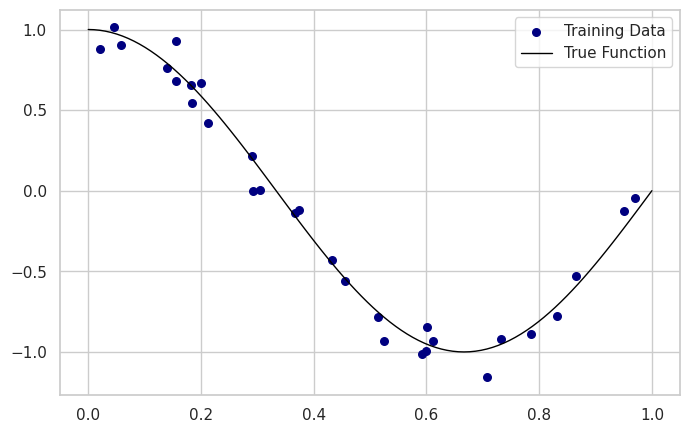

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
np.random.seed(42)

# Generate a sine wave with noise
n_samples = 30
X = np.sort(np.random.rand(n_samples))
y = np.cos(1.5 * np.pi * X) + np.random.randn(n_samples) * 0.1

X = X[:, np.newaxis] # Reshape for sklearn

# Ground Truth function for plotting
X_plot = np.linspace(0, 1, 100)[:, np.newaxis]
y_plot = np.cos(1.5 * np.pi * X_plot)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='navy', s=30, marker='o', label="Training Data")
plt.plot(X_plot, y_plot, color='black', linewidth=1, label="True Function")
plt.legend()
plt.show()

### Visualizing the Extremes

We will compare a Degree 1 model (Line) vs. a Degree 15 model (Complex Curve). **Note**: We use \`Pipeline\` to keep our code clean.

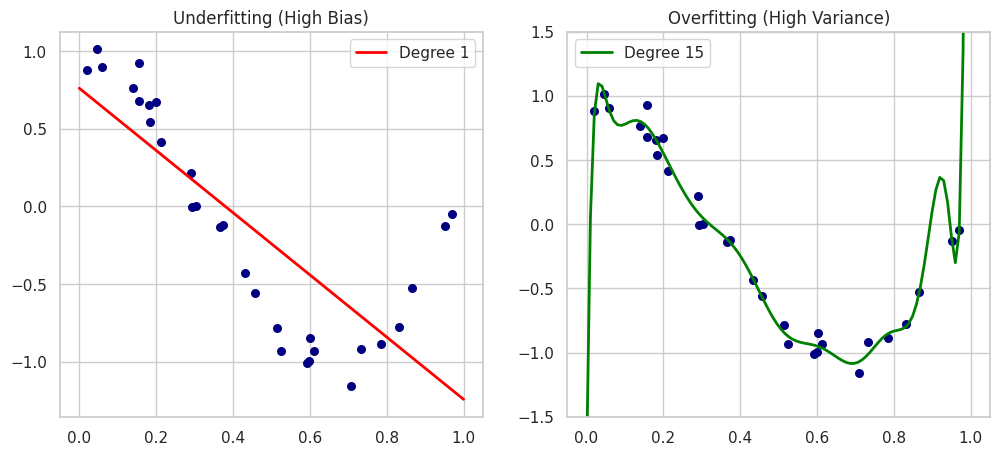

In [2]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

plt.figure(figsize=(12, 5))

# --- Model 1: Underfitting (Degree 1) ---
ax1 = plt.subplot(1, 2, 1)
model_simple = make_pipeline(PolynomialFeatures(degree=1), LinearRegression())
model_simple.fit(X, y)

plt.scatter(X, y, color='navy', s=30)
plt.plot(X_plot, model_simple.predict(X_plot), color='red', linewidth=2, label="Degree 1")
plt.title("Underfitting (High Bias)")
plt.legend()

# --- Model 2: Overfitting (Degree 15) ---
ax2 = plt.subplot(1, 2, 2)
model_complex = make_pipeline(PolynomialFeatures(degree=15), LinearRegression())
model_complex.fit(X, y)

plt.scatter(X, y, color='navy', s=30)
plt.plot(X_plot, model_complex.predict(X_plot), color='green', linewidth=2, label="Degree 15")
plt.title("Overfitting (High Variance)")
plt.ylim(-1.5, 1.5) # Limit y-axis as overfitting tends to explode values
plt.legend()

plt.show()

**Observation**:

-   The Red Line (Left) is too rigid. It ignores the curve.
-   The Green Line (Right) hits every point but oscillates wildly. It has memorized the noise.

## Diagnosing with Learning Curves

How do you detect this if you can't visualize the data (e.g., in 100 dimensions)? We use **Learning Curves**.

-   We plot the Training Score and Validation Score as we add more data.

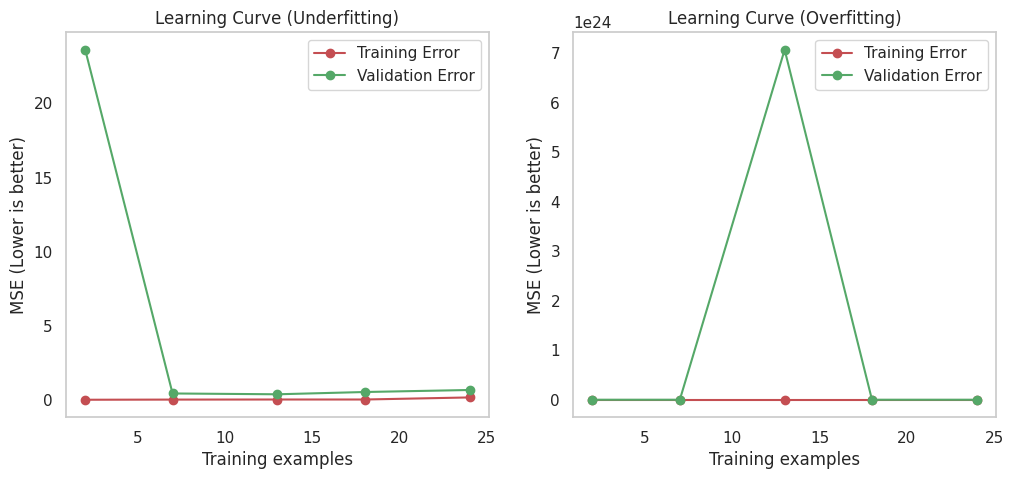

In [3]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='neg_mean_squared_error')

    # Convert negative MSE to positive
    train_scores_mean = -np.mean(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)

    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training Error")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Validation Error")
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("MSE (Lower is better)")
    plt.legend(loc="best")
    plt.grid()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_learning_curve(
    make_pipeline(PolynomialFeatures(degree=1), LinearRegression()),
    "Learning Curve (Underfitting)", X, y)

plt.subplot(1, 2, 2)
plot_learning_curve(
    make_pipeline(PolynomialFeatures(degree=15), LinearRegression()),
    "Learning Curve (Overfitting)", X, y)
plt.show()

**Interpretation**:

-   **Underfitting**: Both errors are high and converge. Adding more data won't help.
-   **Overfitting**: There is a huge "Gap" between Training error (low) and Validation error (high). Adding more data **might** help, or we need to simplify the model.

## Hyperparameter Tuning

To fix these issues, we need to tune the "knobs" of the model (Hyperparameters).

-   **Grid Search**: Tries **every** combination of parameters. Thorough but slow.
-   **Random Search**: Tries **random** combinations. Faster and often just as effective.

### Demonstration: Tuning a Ridge Pipeline

We will try to find the perfect polynomial degree and regularization strength ($\alpha$) simultaneously.

Best Parameters: {'polynomialfeatures__degree': 10, 'ridge__alpha': 0.01}


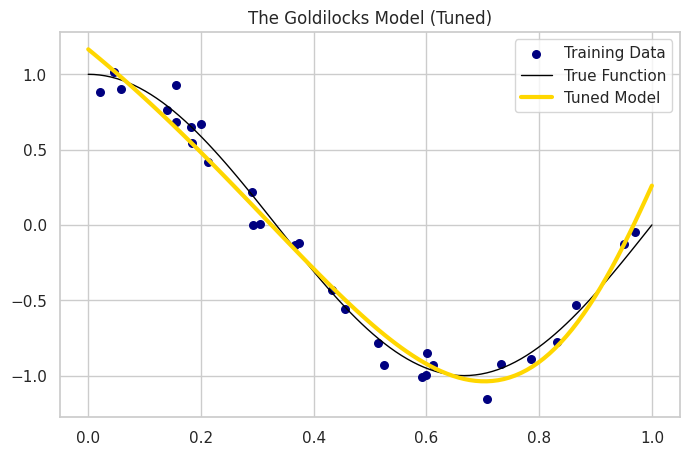

In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

# Create a Pipeline
# Steps: 1. Create Polynomials -> 2. Fit Ridge Regression
pipeline = make_pipeline(PolynomialFeatures(), Ridge())

# Define the Grid
# Note: We access pipeline steps using 'stepname__parameter'
param_grid = {
    'polynomialfeatures__degree': [2, 3, 4, 5, 10],
    'ridge__alpha': [0.001, 0.01, 0.1, 1, 10]
}

# Run Grid Search
search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')
search.fit(X, y)

print("Best Parameters:", search.best_params_)

# Visualizing the Best Model
best_model = search.best_estimator_

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='navy', s=30, label="Training Data")
plt.plot(X_plot, y_plot, color='black', linewidth=1, label="True Function")
plt.plot(X_plot, best_model.predict(X_plot), color='gold', linewidth=3, label="Tuned Model")
plt.title("The Goldilocks Model (Tuned)")
plt.legend()
plt.show()

## Exercises

We will use the **California Housing Dataset**.

### Random Search vs Grid Search

Grid Search explodes in complexity. If you have 4 parameters with 10 options each, that's $10^4 = 10,000$ fits.

-   Use `RandomizedSearchCV` to tune a `Ridge` model on the housing data.
-   Search over `alpha` values ranging from $10^{-3}$ to $10^3$.

In [5]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from scipy.stats import loguniform

# Load Data
data = fetch_california_housing(as_frame=True)
X_house, y_house = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X_house, y_house, test_size=0.2, random_state=42)

# Define Distribution (Log Uniform is best for 'alpha' or 'C')
# It searches equally between 0.001 and 0.01 as it does between 100 and 1000
param_dist = {'alpha': loguniform(1e-3, 1e3)}

# Random Search (n_iter=20 means we only try 20 random combos)
random_search = RandomizedSearchCV(
    Ridge(), param_distributions=param_dist, n_iter=20, cv=3, random_state=42)

random_search.fit(X_train, y_train)

print(f"Best Alpha found: {random_search.best_params_['alpha']:.4f}")
print(f"Best Score (R²):  {random_search.best_score_:.4f}")

Best Alpha found: 0.0013
Best Score (R²):  0.6111


### Fixing Overfitting

Train a Decision Tree Regressor on the housing data. Decision Trees are notorious for overfitting.

1.  Train an unconstrained tree (`max_depth=None`). Check Train vs Test score.
2.  Tune `max_depth` using `GridSearchCV` to fix the overfitting.

In [6]:
from sklearn.tree import DecisionTreeRegressor

# 1. Overfitting Tree
tree_overfit = DecisionTreeRegressor(max_depth=None, random_state=42)
tree_overfit.fit(X_train, y_train)

print("--- Overfitting Tree ---")
print(f"Train Score: {tree_overfit.score(X_train, y_train):.4f} (Perfect Memorization!)")
print(f"Test Score:  {tree_overfit.score(X_test, y_test):.4f}")

# 2. Tuned Tree
tree_grid = {'max_depth': [3, 5, 10, 20]}
tree_search = GridSearchCV(DecisionTreeRegressor(random_state=42), tree_grid, cv=3)
tree_search.fit(X_train, y_train)

print("\n--- Tuned Tree ---")
print(f"Best Depth:  {tree_search.best_params_['max_depth']}")
print(f"Train Score:  {tree_search.score(X_train, y_train):.4f}")
print(f"Test Score:  {tree_search.score(X_test, y_test):.4f}")

--- Overfitting Tree ---
Train Score: 1.0000 (Perfect Memorization!)
Test Score:  0.6221

--- Tuned Tree ---
Best Depth:  10
Train Score:  0.8348
Test Score:  0.6829


**Observation**: The unconstrained tree likely had a Train Score of 1.0 (100%), but a lower Test Score. Limiting the depth (Regularization) lowered the Train Score but improved the Test Score.

## Summary

1.  **Bias vs Variance**: Underfitting vs Overfitting.
2.  **Learning Curves**: A diagnostic tool to visualize the gap between Train and Validation error.
3.  **Tuning**: We use Grid Search (small space) or Random Search (large space) to find the best Hyperparameters.